In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ana-verse-2-0-j/train.parquet
/kaggle/input/ana-verse-2-0-j/sample_submission.parquet
/kaggle/input/ana-verse-2-0-j/test.parquet


In [2]:
train_df=pd.read_parquet("/kaggle/input/ana-verse-2-0-j/train.parquet")
test_df=pd.read_parquet("/kaggle/input/ana-verse-2-0-j/test.parquet")
sample=pd.read_parquet("/kaggle/input/ana-verse-2-0-j/sample_submission.parquet")
# sample.head()
train_df.info(), test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639424 entries, 0 to 1639423
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   Date    1639424 non-null  datetime64[ns]
 1   X1      1639424 non-null  float64       
 2   X2      1639424 non-null  float64       
 3   X3      1639424 non-null  float64       
 4   X4      1639424 non-null  float64       
 5   X5      1639424 non-null  float64       
 6   target  1639424 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 87.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409856 entries, 0 to 409855
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   ID      409856 non-null  int64         
 1   Date    409856 non-null  datetime64[ns]
 2   X1      409856 non-null  float64       
 3   X2      409856 non-null  float64       
 4   X3      409856 no

(None, None)

## Training

In [3]:
train_df['target']=train_df['target'].map({'1':1,'0':0})
df=train_df.copy()
df.head()

,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0


In [4]:
df.isna().sum()

Date      0
X1        0
X2        0
X3        0
X4        0
X5        0
target    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(57315)

In [6]:
df=df.drop_duplicates()
df.head()

,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0


In [7]:
df.describe()

,Date,X1,X2,X3,X4,X5,target
count,1582109,1.582109e+06,1.582109e+06,1.582109e+06,1.582109e+06,1.582109e+06,1.582109e+06
mean,2022-12-07 12:06:52.446931456,1.142747e+00,5.488090e+00,4.259295e+32,2.803710e+29,1.210019e+00,8.869806e-03
min,2020-12-16 00:00:00,1.000000e+00,5.412539e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2021-12-15 00:00:00,1.053376e+00,5.480472e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,2022-12-06 00:00:00,1.107383e+00,5.488855e+00,1.000000e+00,1.000000e+00,6.931472e-01,0.000000e+00
75%,2023-11-28 00:00:00,1.218962e+00,5.496635e+00,1.000000e+00,2.718282e+00,2.890372e+00,0.000000e+00
max,2024-12-11 00:00:00,4.014850e+00,5.541852e+00,1.651636e+38,5.540622e+34,3.465736e+00,1.000000e+00
std,NaN,1.397365e-01,1.345799e-02,2.388275e+35,5.917340e+31,1.310279e+00,9.376107e-02


#### Data Preprocessing

In [8]:
def date_encode(df):
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day']=df['Date'].dt.day
    df['day_of_week'] = df['Date'].dt.dayofweek
    df=df.drop(columns=['Date'])
    return df
df=date_encode(df)
df.head()

,X1,X2,X3,X4,X5,target,year,month,day,day_of_week
0,1.518921,5.463154,1.0,2.718282,2.890372,0,2020,12,16,2
1,1.546509,5.458010,1.0,2.718282,2.833213,1,2020,12,16,2
2,1.645427,5.456560,1.0,7.389056,2.890372,1,2020,12,16,2
3,1.652022,5.458479,1.0,2.718282,2.890372,1,2020,12,16,2
4,1.695538,5.466709,1.0,2.718282,2.890372,0,2020,12,16,2


In [9]:
df['X6']=np.log(df['X2'])
df['X7']=np.log(df['X4'])

#### EDA

In [10]:
# ===== Feature distributions (numeric only) =====
num_cols = ['X1','X2','X3','X4','X5','X6','X7','year','month','day','day_of_week']
# ===== Correlation matrix (numeric only, no heatmap) =====
corr = df[num_cols + ['target']].corr()
print(corr['target'].sort_values(ascending=False))

# ===== Variance filter =====
var = df[num_cols].var()
print(var.sort_values())

target         1.000000
X7             0.375428
X5             0.097736
X1             0.095143
X4             0.045197
X3             0.018852
month          0.002216
day           -0.002170
day_of_week   -0.008828
year          -0.034661
X2            -0.165093
X6            -0.165368
Name: target, dtype: float64
X6             6.019065e-06
X2             1.811175e-04
X1             1.952629e-02
year           1.264198e+00
X5             1.716832e+00
day_of_week    4.022226e+00
month          1.188116e+01
X7             3.519392e+01
day            7.798573e+01
X4             3.501491e+63
X3             5.703856e+70
dtype: float64


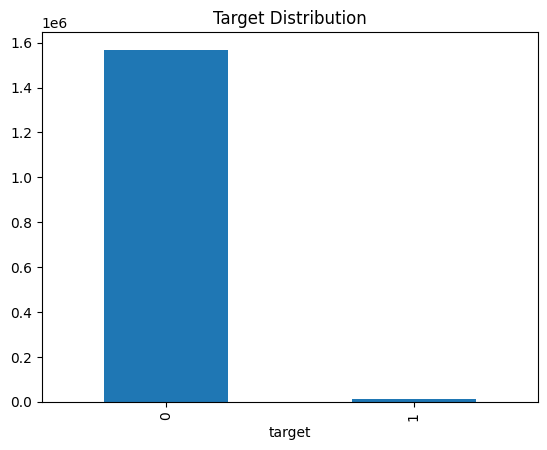

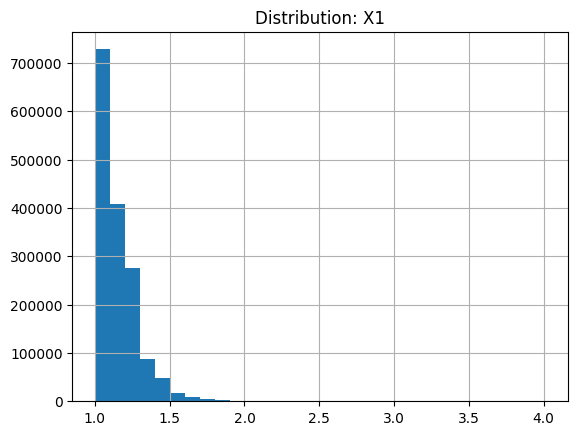

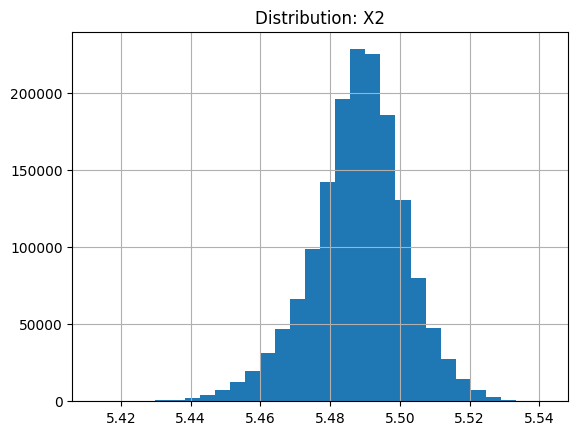

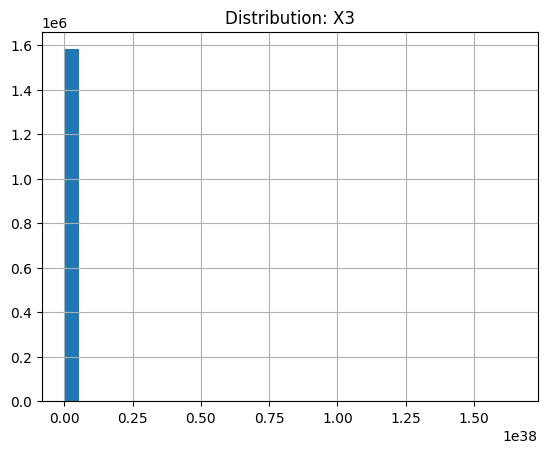

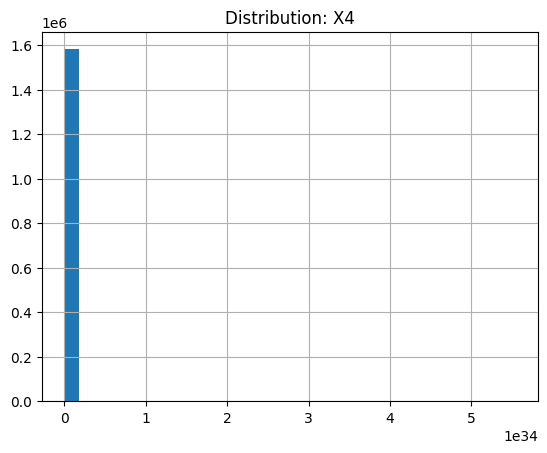

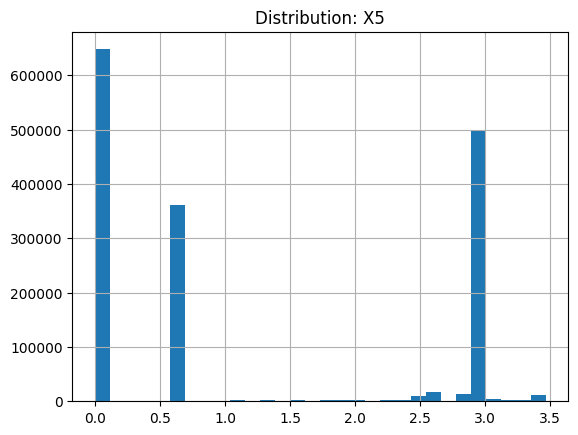

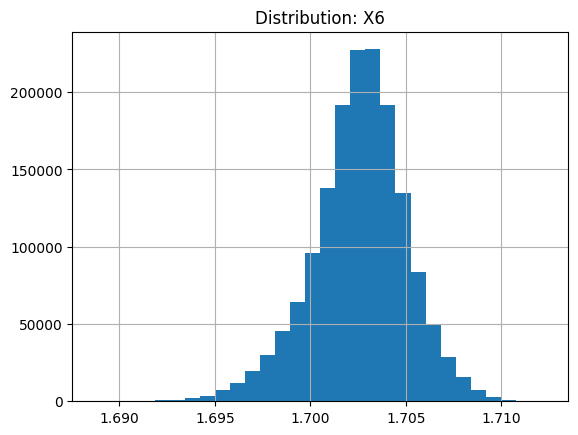

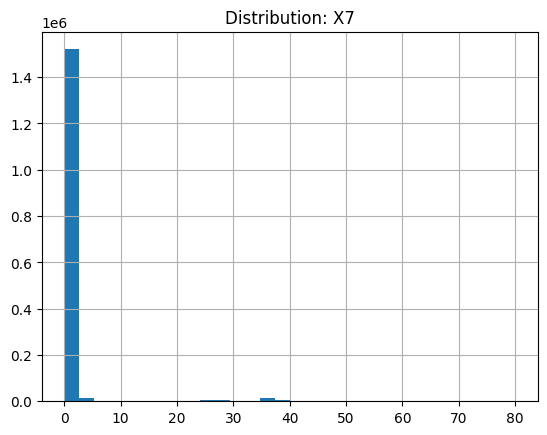

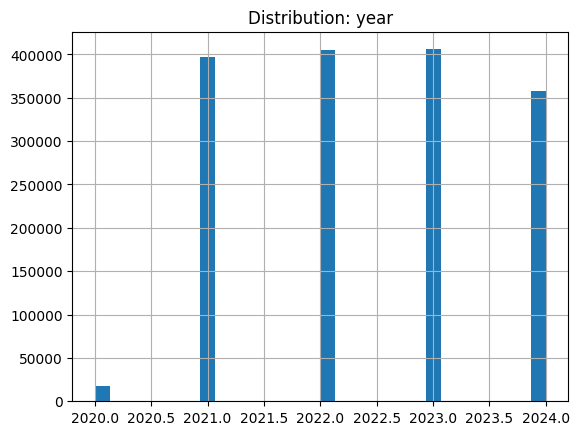

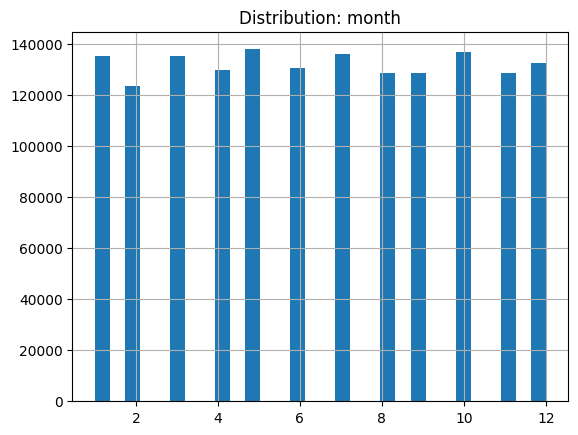

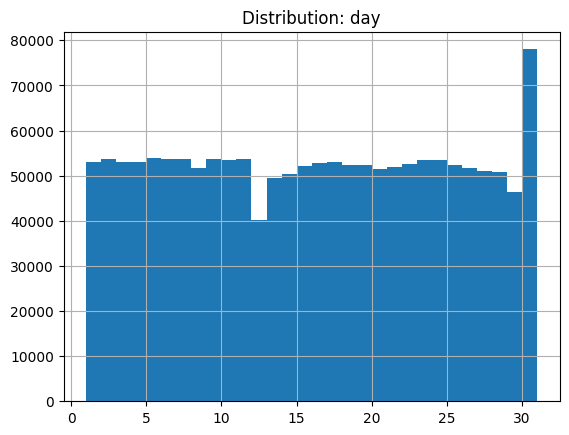

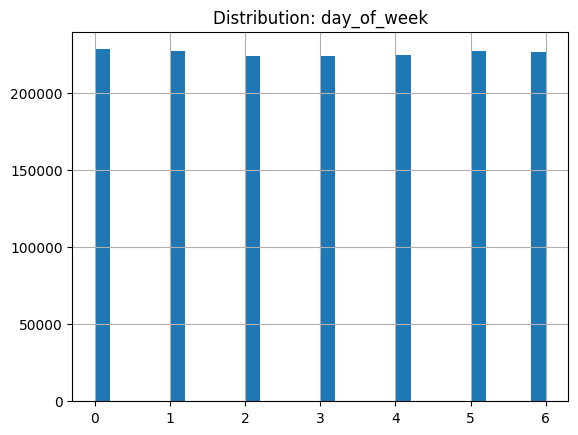

In [11]:
import matplotlib.pyplot as plt

# ===== Target distribution =====
plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.show()

for c in num_cols:
    plt.figure()
    df[c].hist(bins=30)
    plt.title(f"Distribution: {c}")
    plt.show()

#### Model Training

In [12]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

In [13]:
X=df.drop(columns=['target'])
y=df['target']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# XGBClassifier
xgb = XGBClassifier(
    n_estimators=700,
    max_depth=11,
    learning_rate=0.10,
    tree_method="hist",
    device='gpu',
    verbosity=1
)
# find threshold
xgb.fit(X_train, y_train)
y_proba = xgb.predict_proba(X_test)[:,1]
# xgb.classes_
predictions = (y_proba >= 0.38).astype(int)

print(classification_report(y_test, predictions))
f1_score(y_test, predictions)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    313610
           1       0.88      0.78      0.83      2812

    accuracy                           1.00    316422
   macro avg       0.94      0.89      0.91    316422
weighted avg       1.00      1.00      1.00    316422



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [03:27:11] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


0.8279773156899811

In [15]:
# # LightGBM
# from lightgbm import LGBMClassifier

# lgbm = LGBMClassifier(
#     n_estimators=700,       
#     learning_rate=0.05,      
#     max_depth=6,             
#     verbose=-1,
#     device_type='gpu'
# )
# lgbm.fit(X_train, y_train)
# y_proba = lgbm.predict_proba(X_test)[:,1]

# predictions = (y_proba >= 0.38).astype(int)

# print(classification_report(y_test, predictions))
# f1_score(y_test, predictions)

In [16]:
# XGBClassifier > LightGBM

## Test

In [17]:
df_test=test_df.copy()
df_test=date_encode(df_test)
ID=df_test['ID']
df_test=df_test.drop('ID', axis=1)
df_test.head()

,X1,X2,X3,X4,X5,year,month,day,day_of_week
0,1.685395,5.463917,1.0,7.389056,2.890372,2020,12,16,2
1,1.488844,5.454936,1.0,7.389056,2.890372,2020,12,16,2
2,1.164160,5.471136,1.0,1.000000,2.890372,2020,12,16,2
3,1.000000,5.467385,1.0,1.000000,2.890372,2020,12,16,2
4,1.000000,5.453995,1.0,1.000000,2.833213,2020,12,16,2


In [18]:
df_test['X6']=np.log(df_test['X2'])
df_test['X7']=np.log(df_test['X4'])

In [19]:
pred = xgb.predict_proba(df_test)[:,1]
target = (pred >= 0.38).astype(int)

In [20]:
submission=pd.DataFrame({
    "ID":ID,
    "target":target
})

In [21]:
submission.to_csv("submission.csv", index=False)
# df.to_parquet('submission.parquet')